# Project Final Submission Template

### Step 1a: Planning 
#### Identify the information in the file your program will read

Describe (all) the information that is available. Be sure to note any surprising or unusual features. (For example, some information sources have missing data, which may be blank or flagged using values like -99, NaN, or something else.)

<font color="blue">
Reading the txt file tells us that the columns of the CSV file represent:  
    
 - year: the year for the data in a row (integer)
 - month: the month for which the data is about in a row (integer)
 - decimal date: the date written as a decimal to show where the month falls in (float)
 - average: monthly mean CO2 concentrations measured for that month (float)
 - deseasonalize: monthly CO2 concentrations adjusted to remove expected season effects (float)
 - ndays: number of days used to calculate the monthly avergae (integer), -1 represents that number of days were unavailable.
 - sdev: standard deviation of daily CO2 measurments used to calculate monthly avergae (float), -9.99 represents that the standard deviation was not available
 - unc: uncertainty of of monthly average CO2 measurments, -0.99 or 0 represents uncertainty was not available

    
</font>

### Step 1b: Planning 
#### Brainstorm ideas for what your program will produce
#### Select the idea you will build on for subsequent steps

You must brainstorm at least two ideas for graphs or charts that your program could produce and choose the one that you'd like to work on. You can choose between a line chart, histogram, bar chart, scatterplot, or pie chart.

If you would like to change your project idea from what was described in the proposal, you will need to get permission from your project TA. This is intended to help ensure that your new project idea will meet the requirements of the project. Please see the project proposal for things to be aware of when communicating with your project TA.

<font color="blue">
1: Given a CSV file, find the average deseasonalized CO2 concentration per year for all years, which has the number of days available. (Chosen)
    
 - Using the ndays column to filter out all the months that have ndays not available. Done by only taking rows with ndays >-1
 - Using the year and deseasonalized columns to calculate the average deseasonalized CO2 for each year from the filtered list.
 - Using a line chart to show average deseasonalized CO2 concentration per year with year on the x axis and average deseasonalized CO2 concentration on y axis

2: Given 2 years, find the year with higher average CO2 concentration for which the uncertainties are available. (Brainstorm)
 - Using the unc column to filter out rows with no uncertainites. Done by taking only rows with unc>0
 - using the year, month, and average columns to calculate the the average CO2 for the given year done by averaging all the months from the filtered list.
 - Comparing the 2 years for higher CO2 concentration and returing the year with higher average. In case of a tie, return the first one.
 - Use a bar chart to show 2 years average, with year on the x axis and average on the y axis.


</font>

### Step 1c: Planning 
#### Write or draw examples of what your program will produce

You must include an image that shows what your chart or plot will look like. You can insert an image by uploading it into Jupyter via drag and drop and then dragging and dropping it from the sidebar to this cell. Make sure your image is a .png file.

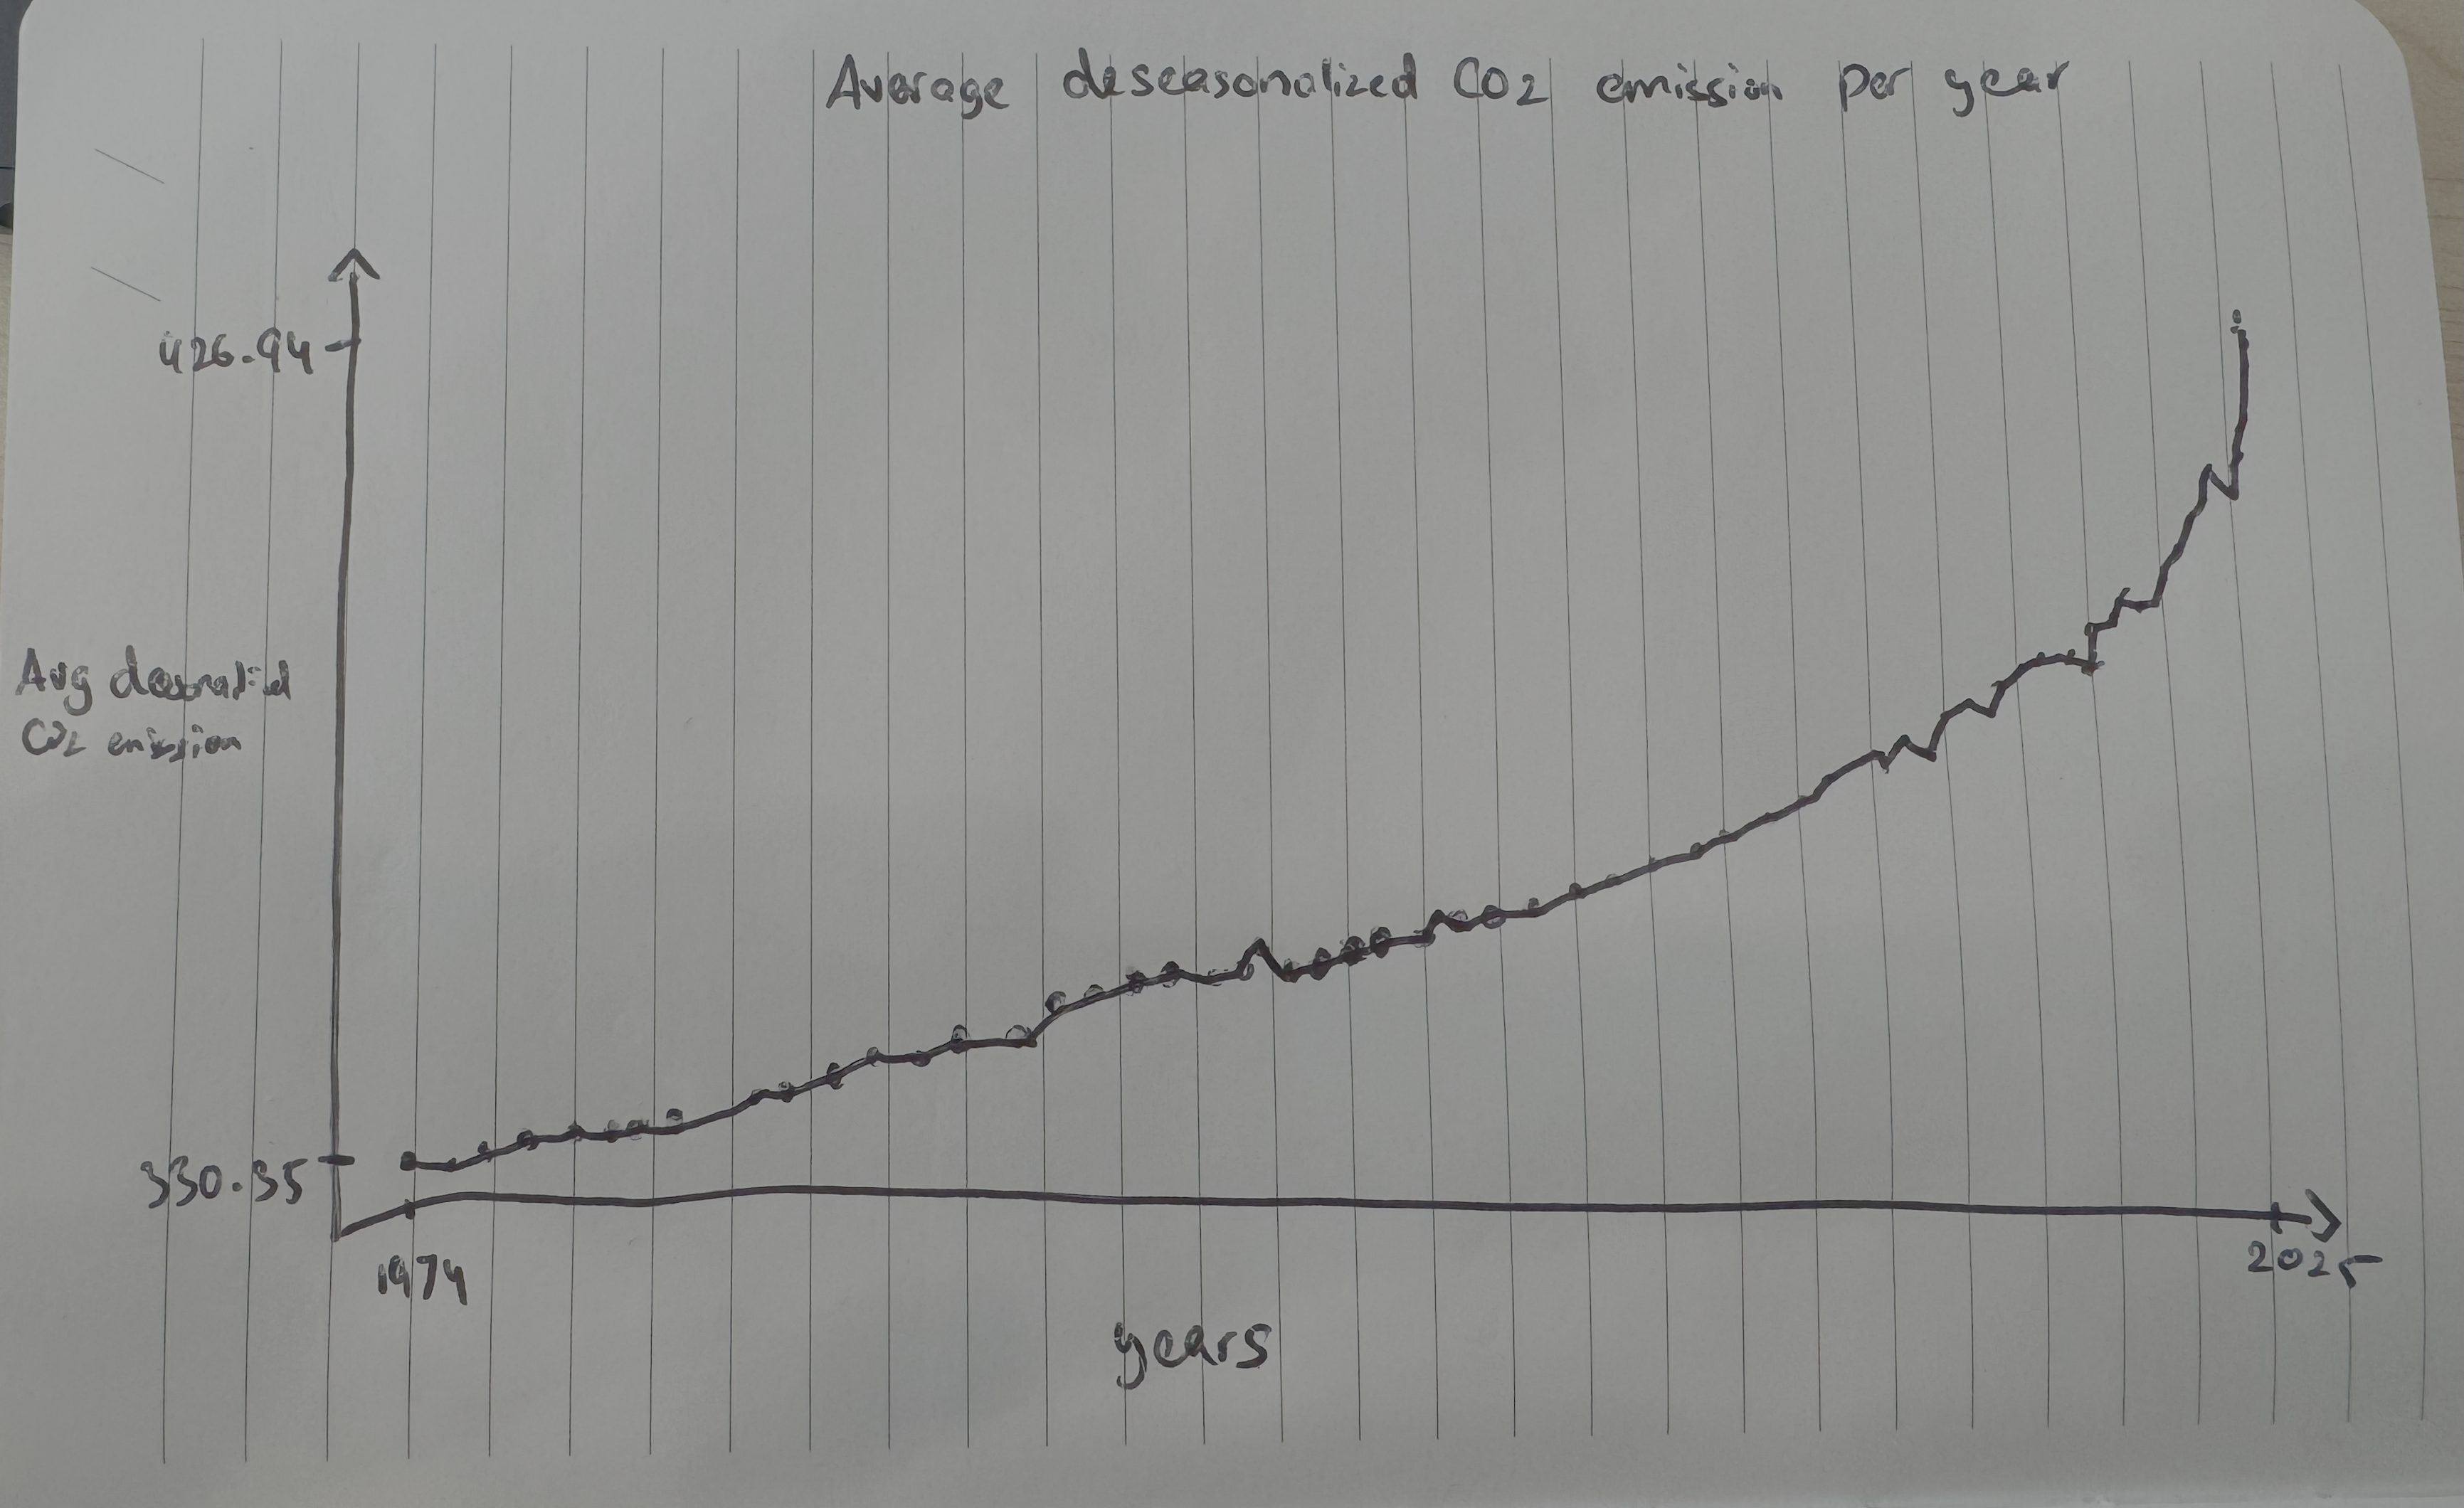

### Step 2a: Building
#### Document which information you will represent in your data definitions

Before you design data definitions in the code cell below, you must explicitly document here which information in the file you chose to represent and why that information is crucial to the chart or graph that you'll produce when you complete step 2c.

<font color="blue">
We are interested in the year and deseasonalized columns to represent in a plot as we are returning a list of average deseasonalized CO2 for all years. We also need the ndays columns to filter out data where the number of days are no available.
    
- Year: Can be represented as an integer interval [0,...)
- Deseasonalized: Can be represented as a float interval [0.0,...)
- Ndays: Can be represented as an integer interval [1,31]

</font>

#### Design the data definitions
<font color="red">**Make sure to indicate which data definition is your data definition that represents a single row of the CSV file by filling in the provided constant `ROW_DATA_DEFINITION`. Without this, our autograders will not be able to grade your submission correctly!!!**</font>

In [1]:
from cs103 import *
from typing import NamedTuple, List
from enum import Enum
import csv
##################
# Data Definitions

#String List
StrList = List[str]
# interp. a list of strings
L0 = []
L1 = ['']
L2 = ['','a','hello']
@typecheck
def fn_for_str_list(sl: StrList) -> ...:
    # template based on arbitrary-sized
    # description of the accumulator
    acc = ...      # type: ...
    for s in sl:
        acc = ...(s, acc)

    return ...(acc)


# Row data
CO2Data = NamedTuple('CO2Data',[('year',int), # in range [0,...)
                                ('deseasonalized',float),# in range [0.0,...)
                               ('ndays',int) # in range [1,31]
                               ]) 
# interp. a monthly CO2 observation containing the year of the data, and the deseasonalized CO2
# concentration, and ndays used to calculate the monthly mean
CD0 = CO2Data(0,0.0,1)
CD1958 = CO2Data(1958,315.301,31)
CD2025 = CO2Data(2025,426.94,5)
CD1974 = CO2Data(1974,330.35,21)
# template based on Compound (3 fields) and reference rule
@typecheck
def fn_for_co2_data(cd: CO2Data) -> ...:
    return ...(cd.year,cd.deseasonalized,cd.ndays)


# CO2DataList
CO2DataList = List[CO2Data]
# interp. a list of CO2Data

CDL0 = []
CDL1 = [CD0]
CDL2 = [CD0,CD1958]
CDL3 = [CD0,CD1958,CD1974,CD2025]

@typecheck
def fn_for_co2_data_list(locd: CO2DataList) -> ...:
    # template based on arbitrary-sized and reference rule
    # description of the accumulator
    acc = ...      # type: ...
    for cd in locd:
        acc = ...(fn_for_co2_data(cd), acc)
    return ...(acc)

# Keep the two variables below where they are. Do not move them to another location in the cell or the file.
ROW_DATA_DEFINITION = CO2Data # replace Consumed with the name of the data type that represents a SINGLE row of the csv file
ROW_LIST_DATA_DEFINITION = CO2DataList # replace ConsumedList with the name of the data type that represents ALL rows

### Step 2b: Reading
#### Design a function to read the information and store it as data in your program

In [2]:
# Put your read function here!
# You can also put the read function in the cell for step 2c but this may cause your cell to become very long
@typecheck
def days_available(sl: StrList) -> bool:
    '''
    returns True when sl contains number of days which are available (not equal to -1) and False when
    the days are unavailable (equal to -1)
    Assumes: sl has rows that are full of values ( at least 6 elements). Specifically, row_data[5] must exist.
    '''
    # return False #stub
    # no template used
    return sl[5]!='-1'

start_testing()
expect(days_available(['0','0','0','0','0','0',]),True)
expect(days_available(['0','0','0','0','0','-1',]),False)
expect(days_available(['1958','123','4342','444','12','-1']),False)
expect(days_available(['1958','123','4342','444','32','21']),True)
summary()


@typecheck
def read(filename: str) -> CO2DataList:
    """    
    reads information from the specified file and returns a list of CO2Data
    Ignores rows where number of days is unavailable (-1)
    """
    #return []  #stub
    # Template from HtDAP
    # aydl contains the result so far
    locd = [] # type: CO2DataList

    with open(filename) as csvfile:
        
        reader = csv.reader(csvfile)
        next(reader) # skip header line

        for row_data in reader:
            # you may not need to store all the strings in the 
            # current row, and you may need to convert some
            # of the strings to other types
            if days_available(row_data):
                cd = CO2Data(parse_int(row_data[0]),parse_float(row_data[4]),parse_int(row_data[5]))
                locd.append(cd)
    
    return locd


# Begin testing
start_testing()

# Examples and tests for read
expect(read('testfile_empty111.csv'), [])
expect(read('testfile_one_valid.csv'),[CO2Data(1999,314.44,1)])
expect(read('testfile_no_valid.csv'),[])
expect(read('testfile_multiple.csv'),[CO2Data(1958,100.0,31),
                                     CO2Data(1958,315.16,20),
                                     CO2Data(1958,315.16,30),
                                     CO2Data(1958,315.16,29),
                                     CO2Data(2025,315.16,25)])
expect(read('testfile_multiple_valid_and_invalid.csv'),
       [CO2Data(1958,0.0,1),
        CO2Data(1958,0.0,31),  
        CO2Data(1958,50.0,20),
        CO2Data(1958,100.0,29),
        CO2Data(1959,5.0,29),
        CO2Data(1959,5.5,30),
        CO2Data(1959,6.35,29),
        CO2Data(1960,100,1),
        CO2Data(1960,100,1),
        CO2Data(1960,100,1)]) #Test 4


# show testing summary
summary()

4 of 4 tests passed
5 of 5 tests passed


### Step 2c: Building
Complete these steps in the code cell below. You will likely want to rename the analyze function so that the function name describes what your analysis function does.

Unless approved by your project TA, you **cannot** use libraries such as `numpy` or `pandas`. The project is meant as a way for you to demonstrate your knowledge of the learning goals in this course. While it is convinent to use external libraries, it will do all the work and will not help us gauge your mastery of the concepts.

You also cannot use built in list functions (e.g., `sum` or `average`) when writing code to do your substantial computation. Normally we encourage you to make use of what is already available but in this case, the final project involves demonstrating skills from class (e.g., how to work with a list). Using pre-built functions for this does not enable you to demonstrate what you know.

If you wish to change your project idea, you must **first** obtain permission from your TA. When contacting your TA, please provide a valid reason for why you want to change your project. Each time you change your topic idea, your TA will have to evaluate it to see if it will meet all of the project requirements. This is non-trivial task during one of the busiest times of the semester. As such, the deadline for project idea changes will be 3 business days before the deadline. Note that the deliverable deadline will not be extended and there is no compensation for the time you spent on the previous idea.

You are welcome to use the Worked Examples from module 8 as a basis for your final project. However, please do make sure you cite the lines of code that you did not write. For example, it is fine to copy/paste the `produce_num_sequence` function from the Module 8 Bar Chart Worked Example. All you need to do is leave a comment above the function that says something like `# lines x to y were copied from the module 8 bar chart worked example`. Lines of code that you did not write are not eligble for grading consideration but are expected to adhere to the principles of code discussed in class (e.g., naming conventions).

In [3]:
# step 1 lower level helpers

# same_year function
@typecheck
def same_year(cd:CO2Data,year:int)->bool:
    '''
    returns True if the year from co2data is the same as inputed year, returns False if not
    '''
    # return True #stub
    # template from CO2Data with additional parameter year
    if cd.year==year:
        return True
    else:
        return False

start_testing()
expect(same_year(CD1958,1958),True) #test for valid year
expect(same_year(CD2025,2024),False) #test for invalid year
summary()

# get_year_avg function
@typecheck
def get_year_avg(year_sum:float,year_count:int)->float:
    '''
    takes the sum of co2 concentrations for one year and the number of
    observations for that year and returns the avg concentration
    ASSUME: a year appears 1 or more times, year_count is either 1 or greater
    '''
    # return 0.0 #stub
    return round(year_sum/year_count,2)
    
start_testing()
expect(get_year_avg(0.0,1),0.0) # test for a year with single data
expect(get_year_avg(100.0,1),100.0) # test for a year with single data
expect(get_year_avg(100.0,2),50.0) # test for a year with multiple data
summary()

2 of 2 tests passed
3 of 3 tests passed


In [4]:
# step 1: builds a list of average deseasonalized CO2 concentrations for each year
# avg_con_per_year = list_of_avg_con(CO2DataList)
@typecheck
def list_of_avg_con(locd: CO2DataList) -> List[float]:
    '''
    returns a list of average deseasonalized CO2 concentrations for each year.
    For years with multiple valid deseasonalized concentrations, average all concentrations
    for the year, if only 1 valid, return that in the list. 
    ASSUME: list is not empty and in ascending order by year
    '''
    #return [] # stub
    # template from CO2DataList
    # stores the average concentrations for each year so far
    acc = []      # type: List[float]
    current_year=locd[0].year
    year_sum = 0.0
    year_count = 0
    for cd in locd:
        # acc = ...(fn_for_co2_data(cd), acc)
        if same_year(cd,current_year):
            year_sum = year_sum + cd.deseasonalized
            year_count = year_count +1
        else:
            acc.append(get_year_avg(year_sum,year_count))
            current_year=cd.year
            year_sum=cd.deseasonalized
            year_count=1
    
    acc.append(get_year_avg(year_sum,year_count))
    return acc

start_testing()
# # test for empty list
# expect(list_of_avg_con([]),[])
# test for 1 year with 1 data
expect(list_of_avg_con(CDL1),[0.0])
# test for 1 year with multiple data
expect(list_of_avg_con([CO2Data(2025,100.1,1),
                        CO2Data(2025,200.2,31),
                        CO2Data(2025,300.30,25),
                        CO2Data(2025,0.0,20),
                        CO2Data(2025,100.1,30),
                        CO2Data(2025,0.1,29)]),[116.8]) 
# test for multiple years with 1 data
expect(list_of_avg_con([CO2Data(0,0.0,1),
                        CO2Data(1958,100.0,31),
                        CO2Data(1959,315.16,25),
                        CO2Data(1960,316.16,20),
                        CO2Data(1961,317.16,30),
                        CO2Data(1962,318.16,29)]),
       [0.0,100.0,315.16,316.16,317.16,318.16]) 
# test for multiple year with multiple data
expect(list_of_avg_con([CO2Data(1958,100.0,1),
                        CO2Data(1958,200.0,31),
                        CO2Data(1958,315.16,25),
                        CO2Data(1960,5.0,20),
                        CO2Data(1960,5.0,30),
                        CO2Data(1961,5.0,29),
                        CO2Data(1961,6.0,29)]),
       [205.05,5.0,5.5]) 
# test for multiple year with single and multiple data data
expect(list_of_avg_con([CO2Data(1958,1.0,1),
                        CO2Data(1958,2.0,31),
                        CO2Data(1959,1.5,25),
                        CO2Data(1960,5.0,20),
                        CO2Data(1960,5.5,30)]),
       [1.5,1.5,5.25]) 
summary()

5 of 5 tests passed


In [5]:
# step 2: builds a list of years
# years = list_of_years(CO2DataList)
@typecheck
def list_of_years(locd:CO2DataList)->List[int]:
    '''
    returns a list of years, if a year appears more than once, merges and returns it once
    ASSUME: List is not empty and is in ascending order by year
    '''
    # return [] #stub
    # template from CO2DataList
    # stores the years appeared so far
    acc = []      # type: List[int]
    current_year=locd[0].year
    for cd in locd:
        # acc = ...(fn_for_co2_data(cd), acc)
        if not same_year(cd,current_year):
            acc.append(current_year)
            current_year=cd.year

    acc.append(current_year)
    return acc
    

start_testing()
# #test for empty
# expect(list_of_years([]),[])
#test for single year once
expect(list_of_years([CO2Data(1958,100.0,1)]),[1958])
#test for single year multiple times
expect(list_of_years([CO2Data(1958,100.0,1),
                        CO2Data(1958,200.0,31),
                        CO2Data(1958,315.16,25)]),[1958])
#test for multiple years multiple times
expect(list_of_years([CO2Data(1958,100.0,1),
                        CO2Data(1958,200.0,31),
                        CO2Data(1959,315.16,25),
                        CO2Data(1959,5.0,20),
                        CO2Data(1960,5.0,30),
                        CO2Data(1960,5.0,29),
                        CO2Data(1960,6.0,29)]),[1958,1959,1960])
#test for multiple years single and multiple times
expect(list_of_years([CO2Data(1958,100.0,1),
                        CO2Data(1958,200.0,31),
                        CO2Data(1959,315.16,25),
                        CO2Data(1960,5.0,20),
                        CO2Data(1960,5.0,30),
                        CO2Data(1961,5.0,29),
                        CO2Data(1961,6.0,29)]),[1958,1959,1960,1961])
summary()

4 of 4 tests passed


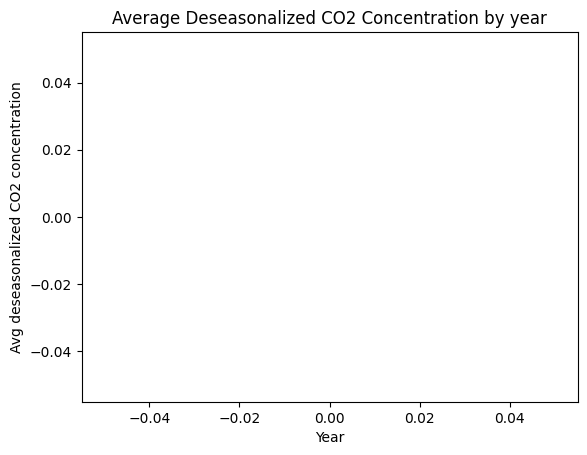

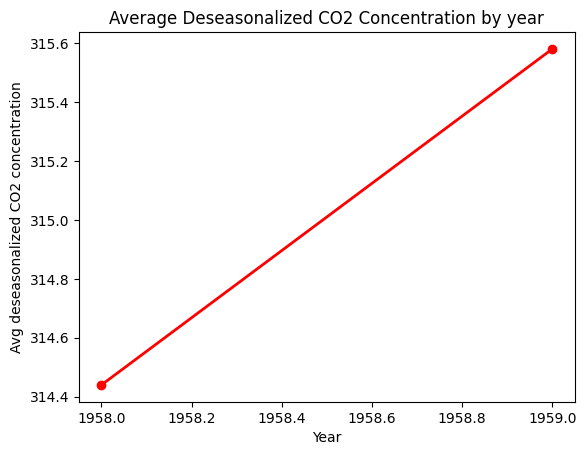

2 of 2 tests passed


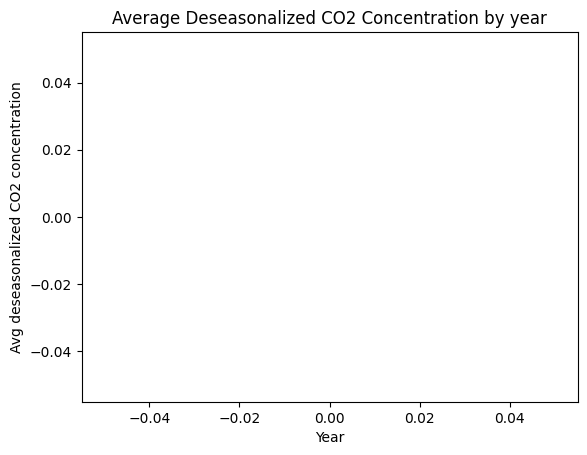

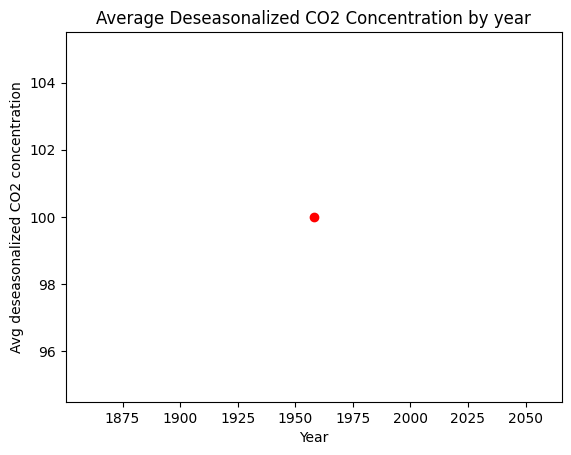

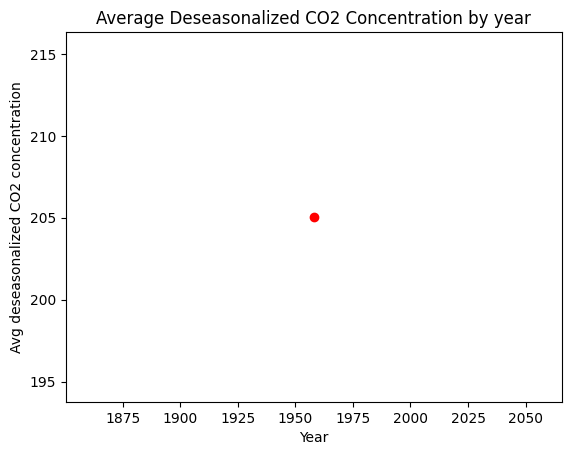

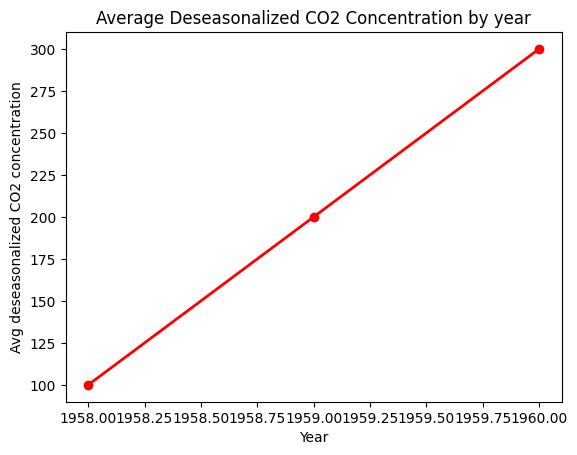

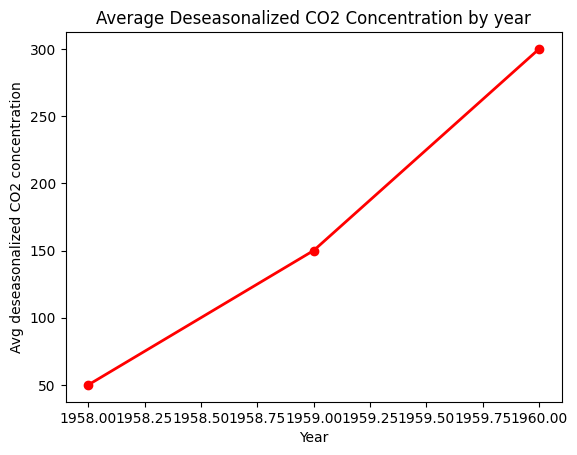

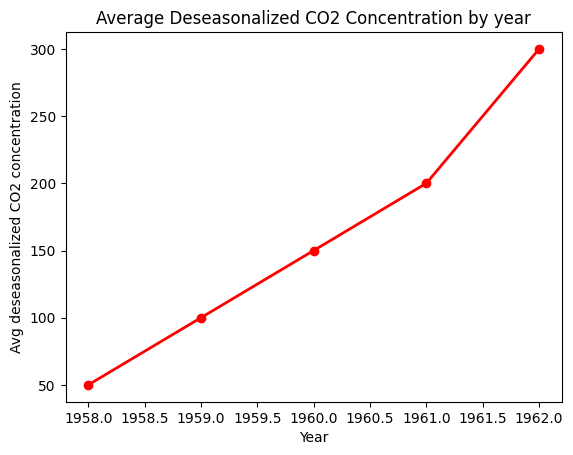

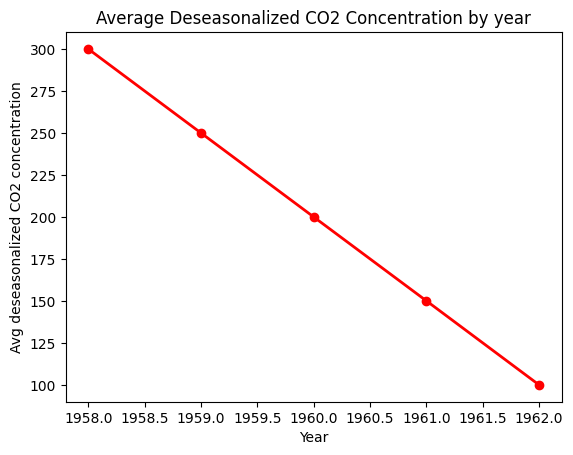

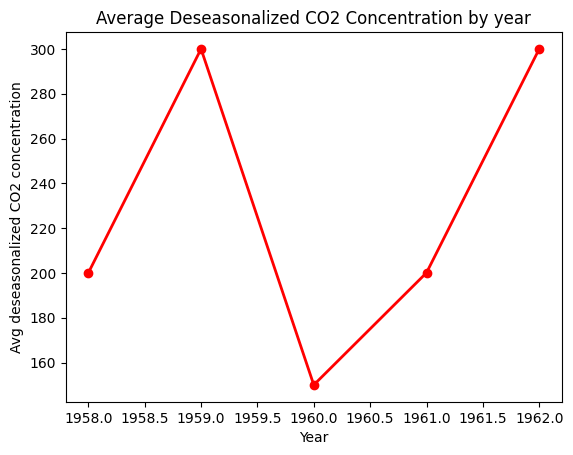

8 of 8 tests passed


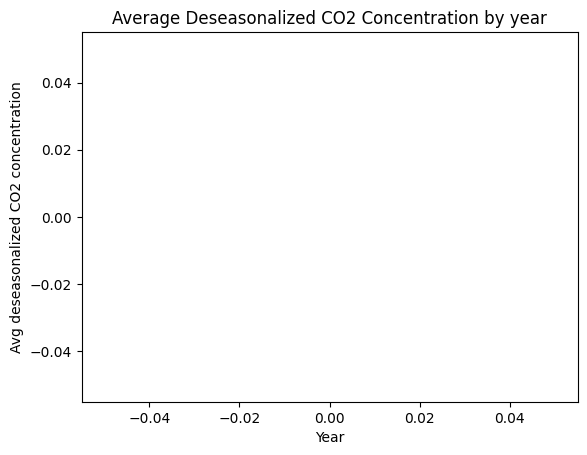

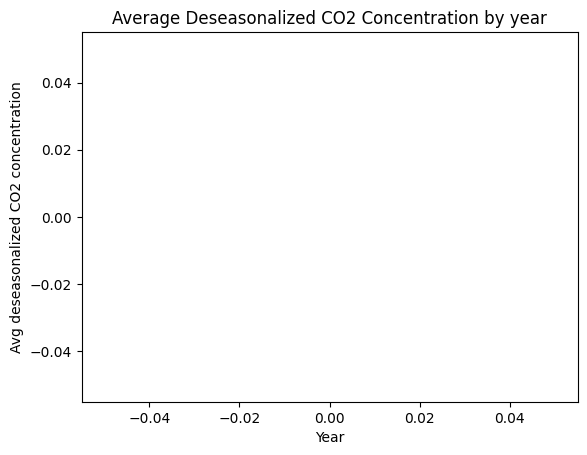

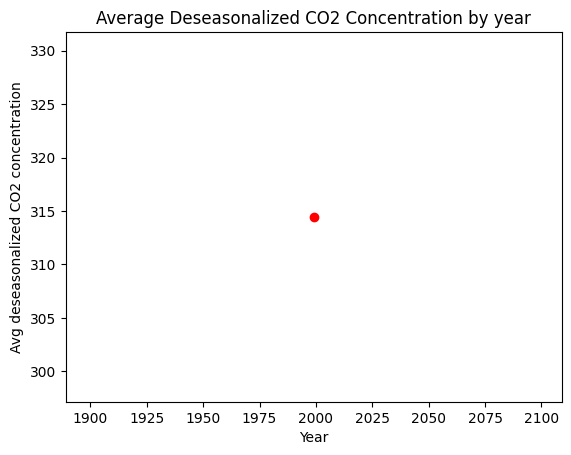

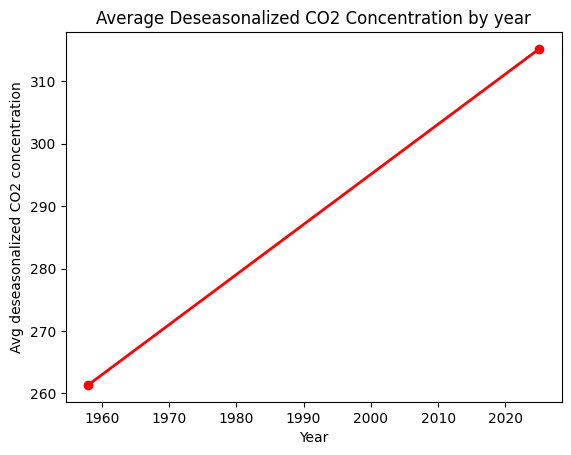

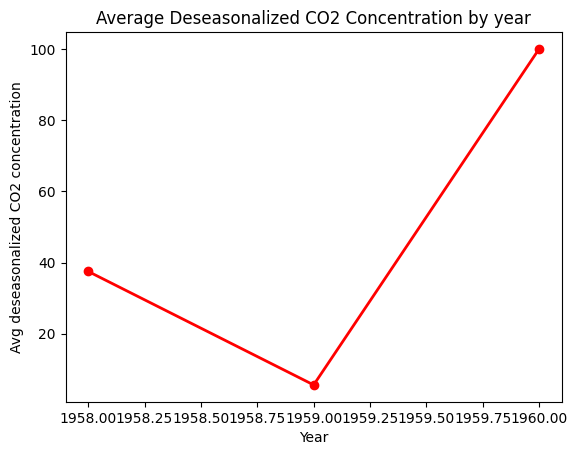

5 of 5 tests passed


In [6]:
###########
# Functions
import matplotlib.pyplot as pyplot

@typecheck
def main(filename: str) -> None:
    """
    Reads the file from given filename, analyzes the data, returns the result 
    """
    # Template from HtDAP, based on function composition 
    return analyze(read(filename)) 
    

    

@typecheck
def analyze(locd: CO2DataList) -> None: 
    """ 
    Plots the average deseasonalized CO2 concentrations for each year where number of days
    are available (not -1)
    """ 

    # return None #stub
    # template based on composition
    # step 1: builds a list of average deseasonalized CO2 concentrations for each year
    # step 2: builds a list of years
    # step 3: plots average concentration per year versus years
    if locd == []:
        plot_filtered_data([],[])
    else: 
        avg_con_per_year = list_of_avg_con(locd)
        years = list_of_years(locd)
        plot_filtered_data(years,avg_con_per_year)
    pyplot.show()
    return None
    
    



@typecheck
def plot_filtered_data(years: List[int],avg_con_per_year: List[float]) -> None:
    '''
    Generates and holds (doesn't show) a line plot of average deseasonalized
    CO2 concentrations for each year
    '''
    # return None # stub
    # Template based on visualization

    # set the x-axis label, y-axis label, and plot title
    pyplot.xlabel('Year')
    pyplot.ylabel('Avg deseasonalized CO2 concentration')
    pyplot.title('Average Deseasonalized CO2 Concentration by year')

    # plot our data 
    line = pyplot.plot(years, avg_con_per_year)
    pyplot.setp(line,color='r',linewidth=2.0,marker='o')
    
    return None
    



# Examples and tests for plot_filtered_data
# Test 1: empty list
# Test 2: valid data
start_testing()
expect(plot_filtered_data([],[]), None)
pyplot.show() # required since plot_filtered_data doesn't show graph itself
# Graph should not show any data points

expect(plot_filtered_data([1958, 1959], [314.44, 315.58]), None)
pyplot.show() # required since plot_filtered_data doesn't show graph itself
# Graph should look like:
#    avg deseasonalized
#    CO2 concentration
# 315.6 | ------o
# 315.2 |     
# 314.8 | 
# 314.4 |o  
# 310.0 +------+- year
#      1958  1959

summary()



# Examples and tests for analyze 
# Test 1: empty list
# Test 2 : 1 valid data
# Test 3 : single year multiple times
# Test 4: Multiple years occuring 1 time
# Test 5: multiple years multiple times
# Test 6: multiple years single and multiple times
start_testing()
# Test 1: empty list
expect(analyze([]),None) # Test 1
# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   100.0 |    
#   80.0  | 
#   60.0  |     
#   40.0  | 
#   20.0  |  
#   0.0   --------- year
#         0       2000

# Test 2 : 1 valid data
expect(analyze([CO2Data(1958,100.0,1)]),None) # Test 2
# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   100.0 |    o
#   80.0  | 
#   60.0  |     
#   40.0  | 
#   20.0  |  
#   0.0   -----+---- year
#         0   1958


# Test 3 : single year multiple times
expect(analyze([CO2Data(1958,100.0,1),
                        CO2Data(1958,200.0,31),
                        CO2Data(1958,315.16,25)]),None) #Test 3
# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   205.0  |    o
#   204.0  | 
#   203.0  |     
#   202.0  | 
#   201.0  |  
#   200.0  ------+---- year
#          0    1958

# Test 4: Multiple years occuring 1 time
expect(analyze([CO2Data(1958,100.0,1),
                        CO2Data(1959,200.0,31),
                        CO2Data(1960,300.0,25)]),None) #Test 4 
# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   300.0  |         ------o
#   250.0  | 
#   200.0  | -------o
#   150.0  | 
#   100.0  |o  
#   50.0   +--------+------+- year
#          1958   1959   1960


# Test 5: multiple years multiple times
expect(analyze([CO2Data(1958,40.0,1),
                        CO2Data(1958,60.0,31),
                        CO2Data(1959,100.0,25),
                        CO2Data(1959,200.0,20),
                        CO2Data(1960,300.0,30),
                        CO2Data(1960,400.0,29),
                        CO2Data(1960,200.0,29)]),None) # Test 5 
# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   300.0  |         ------o
#   250.0  | 
#   200.0  | 
#   150.0  | -------o
#   100.0  |  
#   50.0   o-------+------+- year
#          1958   1959   1960

# Test 6: multiple years single and multiple times
expect(analyze([CO2Data(1958,40.0,1),
                        CO2Data(1958,60.0,31),
                        CO2Data(1959,100.0,25),
                        CO2Data(1960,100.0,20),
                        CO2Data(1960,200.0,30),
                        CO2Data(1961,200.0,29),
                        CO2Data(1961,200.1,29),
               CO2Data(1962,299.99,29)]),None) # Test 6 
# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   300.0  |                  -----o
#   250.0  | 
#   200.0  |            -----o
#   150.0  |      -----o
#   100.0  |-----o
#   50.0   o-----+-----+----+------+ year
#          1958 1959 1960  1961  1962

expect(analyze([CO2Data(1958,300.0,1),
                        CO2Data(1958,300.0,31),
                        CO2Data(1959,250.0,25),
                        CO2Data(1960,200.0,20),
                        CO2Data(1960,200.0,30),
                        CO2Data(1961,100.0,29),
                        CO2Data(1961,200.1,29),
               CO2Data(1962,100.0,29)]),None) # Test 6 
# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   300.0  |o
#   250.0  | -----o
#   200.0  |       -----o
#   150.0  |             ----o
#   100.0  |                  -----o
#   50.0   -+-----+-----+----+-----+ year
#          1958 1959 1960  1961  1962

expect(analyze([CO2Data(1958,200.0,1),
                CO2Data(1958,200.0,31),
                    CO2Data(1959,300.0,25),
                CO2Data(1960,150.0,20),
                CO2Data(1960,150.0,30),
                         CO2Data(1961,150.0,29),
                         CO2Data(1961,200.1,29),
                         CO2Data(1961,250.1,29),
               CO2Data(1962,300.0,29)]),None) # Test 6 
# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   300.0  | -----o           -----o
#   250.0  | 
#   200.0  |o             ---o 
#   150.0  |       -----o     
#   100.0  |                  
#   50.0   -+-----+-----+----+-----+ year
#          1958 1959 1960  1961  1962

summary()

# Examples and tests for main
start_testing()

# Test 1: empty file
# Test 2: invalid data
# Test 3: 1 valid data
# Test 4: multiple valid data
# Test 5: multiple valid and invalid data

# Test 1: empty file
expect(main('testfile_empty111.csv'),None) # Test 1
#   avg deseasonalized
#   CO2 concentration
#   300.0  |
#   250.0  | 
#   200.0  |
#   150.0  |           
#   100.0  |                  
#   0.0    +----+-----+----+-----+ year
#          0 500    1000  1500  2000

# Test 2: invalid data
expect(main('testfile_no_valid.csv'),None) # Test 2
#   avg deseasonalized
#   CO2 concentration
#   300.0  |
#   250.0  | 
#   200.0  |
#   150.0  |           
#   100.0  |                  
#   0.0    +----+-----+----+-----+ year
#          0 500    1000  1500  2000

# Test 3: 1 valid data
expect(main('testfile_one_valid.csv'),None) # Test 3
#   avg deseasonalized
#   CO2 concentration
#   318.0  |
#   317.0  | 
#   316.0  |
#   315.0  |     o    
#   314.0  |                  
#   313.0  |-----+-------year
#          0   1999    2000

# Test 4: multiple valid
expect(main('testfile_multiple.csv'),None) #Test 4

# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   316.0  | 
#   315.0  |      -------o
#   261.25 | ----o        
#   200.0  |          
#   100.0  |                  
#   0.0    -----+-------+ year
#              1958      2025

# Test 5: multiple valid and invalid data
expect(main('testfile_multiple_valid_and_invalid.csv'),None) #Test 5

# Graph should look like:
#   avg deseasonalized
#   CO2 concentration
#   100.0 |        ------o
#   50.0  | 
#   37.5  | o
#   30.0  |       
#   5.62  |  -----o          
#     0.0 --+-----+------+-- year
#          1958  1959  1960

summary()

### Final Graph/Chart

Now that everything is working, you **must** call `main` on the intended information source in order to display the final graph/chart:

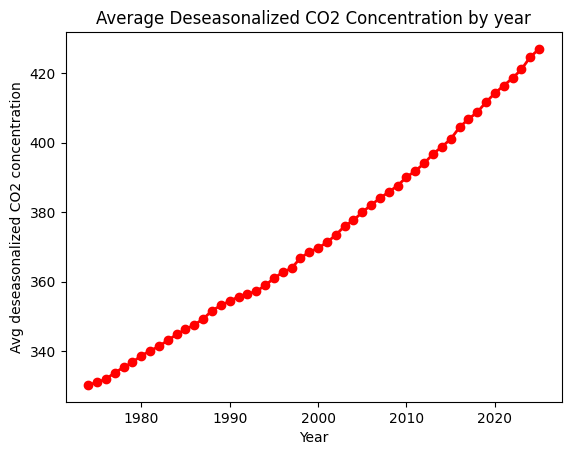

In [7]:
main('co2_mm_mlo.csv')

# <font color="red">Be sure to save in Jupyter AND PrairieLearn</font>
Failure to save in either spot will mean that your work will not be able to be graded.

If you do not save in Jupyter, no one will be able to see the code that you wrote.

If you do not click the "Save" button in PrairieLearn, your work will not appear in the grading queue. We reserve the right to award a zero to submissions that are not submitted through the specified avenue. We will use the last submission that you have saved on **PrairieLearn** for grading purposes.